# Credit Card Fraud Detection Using Machine Learning on Azure
### A Business-Focused Technical Guide
##### by **Nasra Maamiry** for Capstone Project: **CDL20 AI and Data Literacy 2: Data Analytics and Machine Learning Techniques**
##### Github Repsoitory: https://github.com/nasraet/azureml-example/blob/main/jupyter/anomaly_detection_creditcard.ipynb

---

## Executive Summary

This notebook documents a production-ready fraud detection system built on Microsoft Azure's Machine Learning platform. The system automatically learns what "normal" credit card transactions look like, then flags any transaction that deviates significantly from that baseline, without requiring a human to manually review every transaction.

**What problem does this solve?**  
Credit card fraud costs the financial industry tens of billions of dollars annually. Manual review is too slow and too expensive to scale. This system allows a lean operations team to focus human attention only on the transactions most likely to be fraudulent, dramatically reducing both fraud losses and the cost of investigation.

**What does this notebook do?**  
This notebook walks through the complete lifecycle of the fraud detection model:
1. Loading and cleaning real-world transaction data
2. Teaching the model what "normal" looks like
3. Measuring how accurately it catches fraud
4. Deploying it as a live scoring service on Azure

**Who is this for?**  
This document is written for both technical and non-technical stakeholders, including product owners, risk officers, compliance teams, and engineers. Each section includes a plain-language explanation alongside the code.

---

## The Dataset at a Glance

| Property | Detail |
|---|---|
| Source | Real European credit card transactions (publicly available via UCI/Kaggle) |
| Size | ~284,000 transactions over two days |
| Fraud rate | 0.172%, fewer than 2 in every 1,000 transactions are fraudulent |
| Features | 30 numerical variables (28 anonymized via PCA + `Time` + `Amount`) |
| Label | `Class`, 0 = legitimate, 1 = fraudulent |

> **Why is the fraud rate so low?** This extreme imbalance (492 fraud cases vs. 284,315 legitimate ones) is a core challenge. A naïve model that simply labels *everything* as legitimate would be 99.8% accurate, but completely useless. Our approach is specifically designed to overcome this.

---

## ML Pipeline Overview

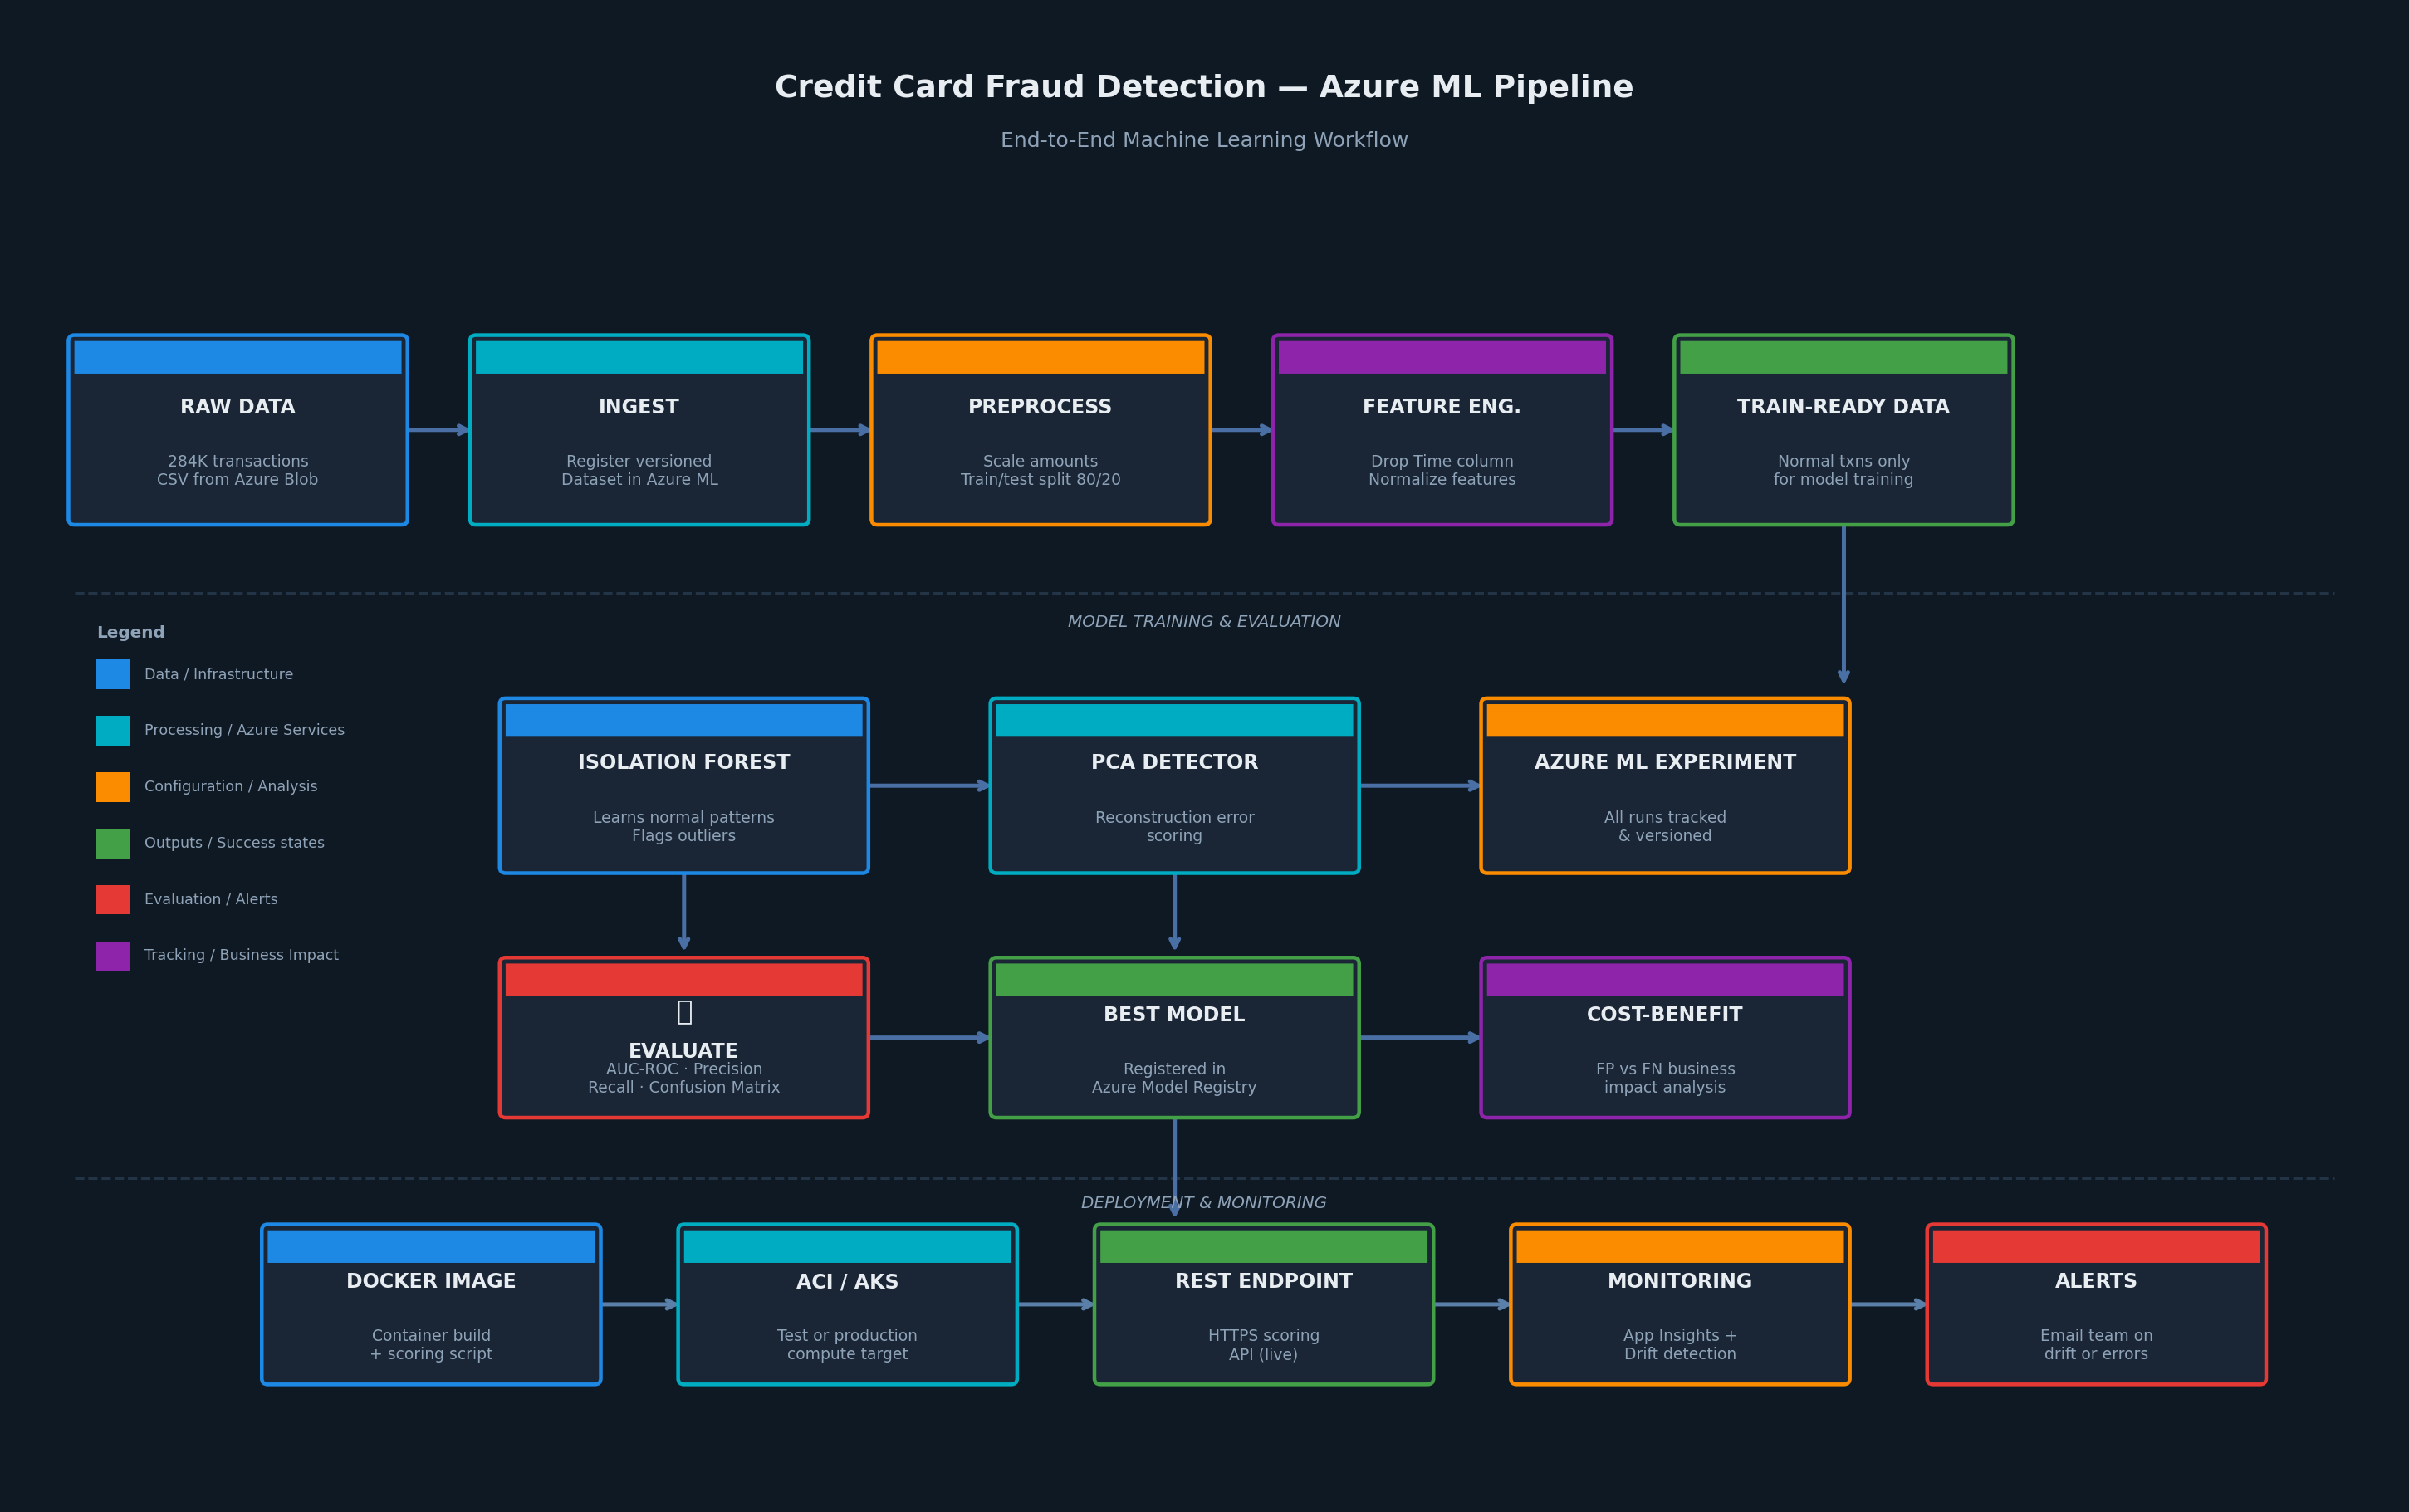

> *Figure: End-to-end pipeline from raw transaction data through preprocessing, model training, evaluation, and Azure deployment.*


---

## Azure ML Components and Their Business Roles

| Azure ML Component | Role in This Solution |
|---|---|
| **Azure ML Workspace** | The central hub, stores all experiments, models, and deployment history. Think of it as the project folder in the cloud. |
| **Azure ML Dataset** | A versioned, governed snapshot of the training data. Ensures the model is always trained on the same, auditable data. |
| **Azure ML Compute Cluster** | On-demand virtual machines that run model training. You only pay while training is running, idle compute costs nothing. |
| **Azure ML Experiment** | A tracked record of every training run, parameters, metrics, and outputs logged automatically for compliance and reproducibility. |
| **Azure ML Model Registry** | A versioned catalog of trained models. Enables rollback to any prior model version if a new one underperforms. |
| **Azure Container Instance (ACI)** | Lightweight deployment target for testing and low-volume scoring. Fast to spin up, low cost. |
| **Azure Kubernetes Service (AKS)** | Production-grade deployment target for high-volume, real-time scoring at scale. Includes auto-scaling and uptime guarantees. |
| **Azure ML Endpoint (REST API)** | The live scoring service. Any application can send a transaction and receive a fraud probability score in milliseconds. |
| **Application Insights** | Real-time monitoring of the deployed model, tracks prediction volumes, latency, errors, and data drift over time. |
| **Azure Key Vault** | Secure storage for API keys and credentials, no secrets stored in code or notebooks. |

---

## Workflow

The steps in this notebook follow the standard **MLOps lifecycle**, the engineering discipline of building, deploying, and maintaining machine learning systems responsibly. Each step is described below in plain terms:

| Step | What Happens | Why It Matters |
|---|---|---|
| **1. Environment Setup** | Connect to Azure, load libraries | Establishes the secure, governed workspace where all work is tracked |
| **2. Data Ingestion** | Load the CSV dataset from Azure Blob Storage | Provides a versioned, auditable copy of training data |
| **3. Exploratory Analysis** | Inspect the data, check for fraud imbalance | Reveals the core challenge: fraud is extremely rare |
| **4. Preprocessing** | Normalize amounts, split train/test sets | Prepares data so the algorithm can learn fairly from it |
| **5. Model Training** | Train Isolation Forest and PCA-based detector | Builds the "brain" that recognizes what normal looks like |
| **6. Evaluation** | Score against held-out test data, generate metrics | Measures how often fraud is caught vs. missed |
| **7. Deployment** | Register model, deploy to REST endpoint | Makes the model available for real-time use in production |
| **8. Monitoring** | Set up Application Insights alerts | Ensures the model stays accurate as transaction patterns evolve |

---
## Step 1: Environment Setup and Azure Connection

### What this step does
Before any data can be processed, we must connect to the **Azure ML Workspace**, the secure, cloud-based environment where all machine learning work is managed. This step:
- Installs required Python libraries (tools the model needs to run)
- Authenticates our identity with Azure (so only authorized users can train or deploy models)
- Confirms we're connected to the correct workspace

### Why this matters to stakeholders
Every action taken from this point forward is logged, versioned, and auditable within the Azure ML Workspace. This is critical for:
- **Compliance**: Regulators can inspect exactly which data was used, when, and by whom
- **Reproducibility**: Any model can be retrained or re-examined at any point in the future
- **Security**: No data or credentials leave the governed Azure environment

In [ ]:
# Install required libraries
# azureml-sdk: Microsoft's official Python SDK for interacting with Azure ML
# scikit-learn: The industry-standard Python machine learning toolkit
# imbalanced-learn: Specialized tools for datasets where one class is rare (like fraud)
!pip install azureml-sdk scikit-learn imbalanced-learn pandas numpy matplotlib seaborn --quiet

In [ ]:
# Core data science libraries
import pandas as pd           # Data manipulation (think: Python's Excel)
import numpy as np            # Numerical computing
import matplotlib.pyplot as plt  # Charting and visualization
import seaborn as sns         # Higher-level statistical charts

# Machine learning tools
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Azure ML SDK, our interface to the Azure cloud platform
from azureml.core import Workspace, Experiment, Dataset, Environment, Model
from azureml.core.compute import AmlCompute, ComputeTarget
from azureml.core.webservice import AciWebservice, AksWebservice
from azureml.core.model import InferenceConfig

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

In [ ]:
# Connect to the Azure ML Workspace
# The config.json file contains the workspace name, subscription ID, and resource group.
# These are pre-configured by your Azure administrator, no manual entry of secrets required.
ws = Workspace.from_config()

print(f"   Connected to Azure ML Workspace: '{ws.name}'")
print(f"   Subscription : {ws.subscription_id}")
print(f"   Resource Group: {ws.resource_group}")
print(f"   Location      : {ws.location}")

---
## Step 2: Data Ingestion

### What this step does
We load the credit card transaction dataset into our workspace and register it as a versioned Azure ML Dataset. The data is sourced from a publicly available benchmark dataset widely used in fraud detection research.

### Understanding the data
Each row represents a single credit card transaction. Here's what each column means:

| Column | Description |
|---|---|
| `Time` | Seconds elapsed since the first transaction in the dataset |
| `V1` – `V28` | Anonymized features (original values transformed to protect cardholder privacy) |
| `Amount` | Transaction value in Euros |
| `Class` | **Our target label**: 0 = Legitimate, 1 = Fraudulent |

### Why anonymized features?
The `V1`–`V28` columns were processed using a mathematical technique called **Principal Component Analysis (PCA)** by the data provider before release. This protects sensitive cardholder information while preserving the statistical patterns the model needs to detect fraud. This is standard practice for sharing financial datasets.

### Data governance note
By registering this dataset in Azure ML, we create a permanent, auditable record of exactly which data was used to train each model version, a key requirement for financial compliance frameworks such as SR 11-7 and GDPR.

In [ ]:
# Load the dataset from Azure Blob Storage
# The dataset URL points to a versioned copy in our Azure Storage Account.
# This ensures all team members train on the identical data.

data_url = 'https://automlsamplenotebookdata.blob.core.windows.net/automl-sample-notebook-data/creditcard.csv'

# Register it as a named, versioned dataset in our workspace
dataset = Dataset.Tabular.from_delimited_files(path=data_url)
dataset = dataset.register(
    workspace=ws,
    name='creditcard-fraud-dataset',
    description='European credit card transactions, 284K rows, 0.172% fraud rate',
    create_new_version=True
)

# Convert to a pandas DataFrame for exploration and preprocessing
df = dataset.to_pandas_dataframe()

print(f" Dataset loaded: {df.shape[0]:,} transactions, {df.shape[1]} columns")
df.head()

---
## Step 3: Exploratory Data Analysis (EDA)

### What this step does
Before training any model, we must deeply understand the data. This step examines the dataset's structure, quality, and the key characteristics that will shape our modeling strategy.

### The Class Imbalance Problem, A Critical Business Consideration

The single most important characteristic of this dataset is its extreme class imbalance: out of roughly 284,000 transactions, fewer than 500 are fraudulent. That's a ratio of approximately **577 legitimate transactions for every 1 fraudulent one**.

**Why does this matter to the business?**

A simplistic model that calls *every* transaction legitimate would achieve 99.8% accuracy, yet it would catch **zero fraud**. This illustrates why accuracy alone is a misleading metric for fraud detection. We must instead optimize for:
- **Recall** (also called Sensitivity): How many fraudulent transactions did we actually catch?
- **Precision**: Of the transactions we flagged as fraud, how many actually were?

These two metrics are in tension with each other, improving one often worsens the other, and the right balance is a **business decision**, not a purely technical one. See Step 6 for a detailed cost-benefit analysis.

In [ ]:
# Basic dataset statistics
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Total transactions  : {len(df):,}")
print(f"Legitimate (Class=0): {(df['Class']==0).sum():,}  ({(df['Class']==0).mean()*100:.3f}%)")
print(f"Fraudulent (Class=1): {(df['Class']==1).sum():,}    ({(df['Class']==1).mean()*100:.3f}%)")
print(f"Missing values      : {df.isnull().sum().sum()}")
print(f"Duplicate rows      : {df.duplicated().sum():,}")
print()
print(df.describe().round(2))

In [ ]:
# Visualize the class imbalance
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dataset Characteristics, Understanding the Fraud Imbalance', fontsize=13)

# Chart 1: Class distribution
class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraudulent'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Transaction Class Distribution')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Chart 2: Transaction amount distribution by class
df[df['Class']==0]['Amount'].hist(bins=50, alpha=0.6, color='#2196F3',
                                   label='Legitimate', ax=axes[1])
df[df['Class']==1]['Amount'].hist(bins=50, alpha=0.8, color='#F44336',
                                   label='Fraudulent', ax=axes[1])
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount (€)')
axes[1].set_xlim(0, 2500)
axes[1].legend()

# Chart 3: Fraud over time
axes[2].scatter(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],
                alpha=0.4, color='#F44336', s=5, label='Fraudulent')
axes[2].set_title('Fraudulent Transactions Over Time')
axes[2].set_xlabel('Time (seconds from start)')
axes[2].set_ylabel('Amount (€)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Key Insight: Fraud transactions tend to cluster at lower amounts, likely to avoid detection thresholds.")

---
## Step 4: Data Preprocessing

### What this step does
Raw data is almost never ready for a machine learning model as-is. This step transforms the data into a form the model can learn from effectively.

### Preprocessing actions and their business rationale

**1. Feature Scaling (Normalizing the `Amount` column)**  
The `Amount` column ranges from €0 to €25,691. The `V1`–`V28` columns, by contrast, hover around zero. Without scaling, the model would pay disproportionate attention to `Amount` simply because its numbers are larger, not because it's more informative. Scaling brings all features onto the same playing field.

*Business analogy: Comparing employee performance using a mix of metrics in different units, like salary (in thousands) alongside a 1–5 satisfaction score, without normalizing would skew any composite ranking.*

**2. Dropping the `Time` column**  
The raw `Time` feature (seconds since dataset start) contains no absolute time-of-day information and has been shown to add noise. It is removed to improve model focus.

**3. Train / Test Split (80% / 20%)**  
We divide the data into two non-overlapping groups:
- **Training set (80%)**: What the model learns from
- **Test set (20%)**: A completely held-out set the model never sees during training, used only to measure real-world performance

*Business analogy: Training on past exams but being tested on a brand-new exam you've never seen. This prevents the model from "memorizing" the answers instead of truly learning the pattern.*

**4. Anomaly Detection Training Strategy**  
Our chosen algorithms (Isolation Forest and PCA-based detector) are **unsupervised anomaly detectors**, they learn exclusively on normal (non-fraudulent) transactions. This mimics real-world conditions where labeled fraud examples are rare and may not represent future fraud patterns.

In [ ]:
# Step 4a: Feature Engineering

# Scale the Amount column to match the scale of V1-V28
# StandardScaler transforms values so they have a mean of 0 and std dev of 1
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Drop the original Amount (replaced by scaled version) and Time (not informative)
df_processed = df.drop(columns=['Time', 'Amount'])

# Separate features (X) from labels (y)
# X = everything the model uses to make predictions
# y = the correct answer (0=legitimate, 1=fraud), used only for evaluation
X = df_processed.drop(columns=['Class'])
y = df_processed['Class']

print(f"   Features matrix shape: {X.shape}  ({X.shape[0]:,} transactions × {X.shape[1]} features)")
print(f"   Label vector shape  : {y.shape}")

In [ ]:
# Step 4b: Train/Test Split
# stratify=y ensures the fraud rate is the same in both train and test sets
# random_state=42 ensures reproducibility, same split every time this runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y      # Critical: maintain fraud ratio in both splits
)

# Step 4c: Isolate only NORMAL transactions for training
# Anomaly detectors learn what "normal" looks like, they don't need fraud examples to train
X_train_normal = X_train[y_train == 0]

print("    Data split complete:")
print(f"   Training set (normal only): {len(X_train_normal):,} transactions")
print(f"   Test set (all classes)    : {len(X_test):,} transactions")
print(f"   Test set fraud count      : {y_test.sum():,} ({y_test.mean()*100:.3f}%)")

---
## Step 5: Model Training

### What this step does
We train two complementary anomaly detection algorithms and log all experiments to Azure ML for traceability.

### Why two models?

No single algorithm is perfect for all fraud patterns. By training two models with fundamentally different approaches, we can:
- Compare their performance on real data
- Use one as a fallback if the other degrades over time
- Potentially ensemble (combine) them for higher accuracy

### Algorithm Explainers (Plain Language)

**Model 1: Isolation Forest**  
Imagine sorting a deck of cards by randomly cutting the deck repeatedly. Normal cards (common values) take many cuts to isolate. Rare, unusual cards (anomalies like fraud) tend to get isolated in very few cuts. The Isolation Forest algorithm applies this same logic: transactions that are easy to isolate are likely fraudulent.

*Key tuning parameter, `contamination`:* This tells the model roughly what fraction of transactions to expect as anomalous. We set this to match the known fraud rate (~0.172%). Getting this right is critical, too high and we generate too many false alarms; too low and we miss real fraud.

**Model 2: PCA-Based Anomaly Detector**  
PCA (Principal Component Analysis) compresses the 29 transaction features into a smaller set of key patterns. After learning these patterns from normal transactions, it then attempts to reconstruct any new transaction from those patterns. Fraudulent transactions are structurally different from normal ones, they reconstruct poorly, resulting in a high **reconstruction error** that signals an anomaly.

### Azure ML Experiment Tracking
Every training run is recorded in an Azure ML **Experiment**, logging the algorithm, parameters, dataset version, training duration, and performance metrics. This creates a complete audit trail and allows teams to compare all past runs side-by-side in Azure ML Studio.

In [ ]:
# Create (or connect to) an Azure ML Experiment
# An Experiment is a named container for related training runs in Azure ML Studio
experiment = Experiment(workspace=ws, name='creditcard-fraud-detection')
print(f" Experiment '{experiment.name}' ready in workspace '{ws.name}'")

In [ ]:
# Model 1: Isolation Forest
# Start a new tracked run in Azure ML, all metrics logged here appear in Azure ML Studio
with experiment.start_logging() as run:
    run.log('model_type', 'IsolationForest')
    run.log('dataset_version', dataset.version)
    run.log('training_samples', len(X_train_normal))

    # contamination: expected proportion of anomalies in the dataset
    # n_estimators: number of "isolation trees", more = more stable but slower
    # random_state: ensures reproducible results
    iso_forest = IsolationForest(
        contamination=0.00172,  # Matches known fraud rate in this dataset
        n_estimators=200,       # 200 trees provides stable estimates
        max_samples='auto',     # Automatically selects optimal subsample size
        random_state=42
    )

    iso_forest.fit(X_train_normal)  # Train ONLY on normal transactions

    # Generate predictions on the test set
    # Isolation Forest outputs: 1 = normal (inlier), -1 = anomaly (outlier)
    # We convert to 0/1 to match our label convention
    iso_preds_raw = iso_forest.predict(X_test)
    iso_preds = (iso_preds_raw == -1).astype(int)  # -1 → fraud=1, 1 → normal=0

    # Anomaly score: lower (more negative) = more anomalous
    iso_scores = -iso_forest.score_samples(X_test)  # Flip sign: higher = more anomalous

    # Log performance metrics to Azure ML
    auc = roc_auc_score(y_test, iso_scores)
    avg_prec = average_precision_score(y_test, iso_scores)
    run.log('auc_roc', round(auc, 4))
    run.log('average_precision', round(avg_prec, 4))

    run_id_iso = run.id

print(f"   Isolation Forest trained, AUC-ROC: {auc:.4f}  |  Avg Precision: {avg_prec:.4f}")
print(f"   Azure ML Run ID: {run_id_iso}")

In [ ]:
# Model 2: PCA-Based Anomaly Detector
with experiment.start_logging() as run:
    run.log('model_type', 'PCA_AnomalyDetector')
    run.log('dataset_version', dataset.version)
    run.log('training_samples', len(X_train_normal))

    # n_components: how many principal components (compressed dimensions) to retain
    # 0.95 means: keep enough components to explain 95% of variance in normal data
    pca = PCA(n_components=0.95, random_state=42)
    pca.fit(X_train_normal)  # Learn the "shape" of normal transactions

    # Reconstruct test transactions from the learned normal patterns
    X_test_reconstructed = pca.inverse_transform(pca.transform(X_test))

    # Reconstruction error: how different is each transaction from what "normal" would look like?
    # High error = the transaction doesn't fit normal patterns = likely fraudulent
    reconstruction_error = np.mean(np.power(X_test.values - X_test_reconstructed, 2), axis=1)

    # Determine fraud threshold: any transaction with error above this is flagged
    # We use the 99.828th percentile of normal transaction errors
    # (matching the expected 0.172% fraud rate)
    threshold = np.percentile(reconstruction_error[y_test == 0], 100 * (1 - 0.00172))
    pca_preds = (reconstruction_error > threshold).astype(int)

    # Log metrics
    auc_pca = roc_auc_score(y_test, reconstruction_error)
    avg_prec_pca = average_precision_score(y_test, reconstruction_error)
    run.log('auc_roc', round(auc_pca, 4))
    run.log('average_precision', round(avg_prec_pca, 4))
    run.log('reconstruction_threshold', round(float(threshold), 6))

    run_id_pca = run.id

print(f"   PCA Detector trained , AUC-ROC: {auc_pca:.4f}  |  Avg Precision: {avg_prec_pca:.4f}")
print(f"   Reconstruction error threshold: {threshold:.6f}")
print(f"   Azure ML Run ID: {run_id_pca}")

---
## Step 6: Performance Evaluation and Business Impact Assessment

### What this step does
We rigorously evaluate both models against the held-out test set using multiple performance metrics. More importantly, we translate these metrics into concrete business outcomes to guide decision-making.

### Metric Dictionary, What Each Number Means

| Metric | Plain-Language Definition | Why It Matters |
|---|---|---|
| **True Positive (TP)** | Fraud correctly flagged as fraud | Every TP = a fraud case that was stopped |
| **False Positive (FP)** | Legitimate transaction wrongly flagged as fraud | Every FP = a frustrated customer whose transaction was declined |
| **False Negative (FN)** | Fraud that slipped through undetected | Every FN = a fraud loss that hit the business |
| **True Negative (TN)** | Legitimate transaction correctly approved | The vast majority of all transactions |
| **Precision** | Of all fraud flags raised, what % were real fraud? | High precision = fewer false alarms |
| **Recall (Sensitivity)** | Of all actual fraud events, what % did we catch? | High recall = fewer missed frauds |
| **F1 Score** | Harmonic mean of Precision and Recall | Single balanced measure of detection quality |
| **AUC-ROC** | Overall discriminating ability across all thresholds (0.5=random, 1.0=perfect) | Model quality benchmark |
| **AUC-PR** | Precision-Recall curve area, more meaningful for imbalanced datasets | Better metric than ROC for rare-event detection |

---

### Cost-Benefit Analysis: False Positives vs. Missed Fraud

The core business tradeoff in fraud detection is **not purely technical**, it requires explicit business input on the relative costs of two types of error:

**Cost of a False Positive (calling good a transaction fraudulent):**
- Customer inconvenience / declined card at point of sale
- Customer service call cost: ~\$5–\$15 per incident
- Risk of customer churn: losing a profitable account
- Reputational damage if high-value customers are affected
- Estimated cost: **\$10–\$50 per false alarm**

**Cost of a False Negative (missing real fraud):**
- Direct financial loss of the fraudulent transaction
- Chargeback fees: typically \$20–\$100 per dispute plus the transaction amount
- Investigation and remediation costs
- Regulatory penalties if systemic fraud patterns are missed
- Estimated cost: **\$150–\$1,000+ per missed fraud event** (average fraud transaction ~\$150)

**Implication for model tuning:**  
Given that missing fraud typically costs 5–20× more than a false alarm, the model threshold should be biased toward **higher recall (catch more fraud)** even at the cost of somewhat lower precision (more false alarms). The optimal operating point depends on your specific fraud loss rate and customer sensitivity, this is a parameter that business and risk leadership should set, not data scientists alone.

---

### Risk Assessment and Mitigation Strategies

| Risk | Likelihood | Impact | Mitigation |
|---|---|---|---|
| **Model Drift**, fraud patterns evolve over time | High | High | Retrain quarterly; monitor data drift with Azure ML |
| **Adversarial Attacks**, fraudsters learn the model's weaknesses | Medium | High | Regular red-team testing; ensemble multiple models |
| **Imbalance Shift**, fraud rate changes significantly | Medium | Medium | Alert on fraud rate changes; retrain with updated data |
| **False Positive Spike**, innocent customers blocked en masse | Low | Very High | Set hard cap on daily FP rate; human review queue for borderline cases |
| **Data Quality Issues**, corrupted or delayed transaction features | Medium | High | Input validation in scoring service; anomaly checks on feature distributions |
| **Regulatory Non-Compliance** | Low | Very High | Full audit trail via Azure ML; explainability layer for flagged decisions |

---

### Stakeholder Communication Plan, Model Limitations

**What the model can do:**
- Flag statistically unusual transactions in milliseconds at scale
- Reduce manual review workload by prioritizing the highest-risk cases
- Operate 24/7 without human fatigue or inconsistency

**What the model cannot do:**
- Catch 100% of fraud (some fraud is designed to look normal)
- Guarantee zero false positives (some legitimate transactions look unusual)
- Explain its decisions in intuitive human terms without additional tooling
- Maintain accuracy indefinitely without retraining as fraud tactics evolve

**Recommended communication cadence:**
- **Weekly**: Fraud operations team receives automated dashboard with TP/FP/FN counts, model score distributions
- **Monthly**: Risk committee receives summary of model performance vs. prior month and business impact metrics
- **Quarterly**: Model review with data science team, assess need for retraining or threshold adjustment
- **Annually**: Full model validation report for compliance and audit

In [ ]:
# Confusion Matrix and Classification Report, Model 1: Isolation Forest
print("=" * 60)
print("MODEL 1: ISOLATION FOREST, PERFORMANCE REPORT")
print("=" * 60)
cm_iso = confusion_matrix(y_test, iso_preds)
tn, fp, fn, tp = cm_iso.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives  (legitimate, correctly approved): {tn:,}")
print(f"  False Positives (legitimate, wrongly flagged)   : {fp:,}  ← customer friction")
print(f"  False Negatives (fraud, missed by model)        : {fn:,}  ← fraud losses")
print(f"  True Positives  (fraud, correctly caught)       : {tp:,}  ← value delivered")
print()
print(f"  Fraud Caught    : {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}% (Recall)")
print(f"  False Alarm Rate: {fp}/{fp+tn} = {fp/(fp+tn)*100:.3f}% of legitimate transactions")
print()
print(classification_report(y_test, iso_preds, target_names=['Legitimate', 'Fraudulent']))

In [ ]:
# Confusion Matrix and Classification Report, Model 2: PCA Detector
print("=" * 60)
print("MODEL 2: PCA ANOMALY DETECTOR, PERFORMANCE REPORT")
print("=" * 60)
cm_pca = confusion_matrix(y_test, pca_preds)
tn2, fp2, fn2, tp2 = cm_pca.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives  (legitimate, correctly approved): {tn2:,}")
print(f"  False Positives (legitimate, wrongly flagged)   : {fp2:,}")
print(f"  False Negatives (fraud, missed by model)        : {fn2:,}")
print(f"  True Positives  (fraud, correctly caught)       : {tp2:,}")
print()
print(f"  Fraud Caught    : {tp2}/{tp2+fn2} = {tp2/(tp2+fn2)*100:.1f}% (Recall)")
print(f"  False Alarm Rate: {fp2}/{fp2+tn2} = {fp2/(fp2+tn2)*100:.3f}% of legitimate transactions")
print()
print(classification_report(y_test, pca_preds, target_names=['Legitimate', 'Fraudulent']))

In [ ]:
# Visual Performance Comparison, ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison, Higher and More Left is Better', fontsize=13)

# ROC Curves
fpr_iso, tpr_iso, _ = roc_curve(y_test, iso_scores)
fpr_pca, tpr_pca, _ = roc_curve(y_test, reconstruction_error)

axes[0].plot(fpr_iso, tpr_iso, color='#2196F3', lw=2,
             label=f'Isolation Forest (AUC={auc:.3f})')
axes[0].plot(fpr_pca, tpr_pca, color='#FF9800', lw=2,
             label=f'PCA Detector (AUC={auc_pca:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Baseline (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate (% of Legit Transactions Blocked)')
axes[0].set_ylabel('True Positive Rate (% of Fraud Caught)')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall Curves (more informative for imbalanced datasets)
prec_iso, rec_iso, _ = precision_recall_curve(y_test, iso_scores)
prec_pca, rec_pca, _ = precision_recall_curve(y_test, reconstruction_error)

axes[1].plot(rec_iso, prec_iso, color='#2196F3', lw=2,
             label=f'Isolation Forest (AP={avg_prec:.3f})')
axes[1].plot(rec_pca, prec_pca, color='#FF9800', lw=2,
             label=f'PCA Detector (AP={avg_prec_pca:.3f})')
axes[1].axhline(y=0.00172, color='k', linestyle='--', alpha=0.4,
                label='Random Baseline (0.172% fraud rate)')
axes[1].set_xlabel('Recall (Fraction of Fraud Caught)')
axes[1].set_ylabel('Precision (Fraction of Flags That Are Real Fraud)')
axes[1].set_title('Precision-Recall Curve\n(Key metric for imbalanced fraud datasets)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Business Impact Simulation
# Using illustrative cost assumptions, replace with your organization's actual figures

print("=" * 60)
print("ESTIMATED BUSINESS IMPACT, ISOLATION FOREST (per test period)")
print("=" * 60)

avg_fraud_amount = 150      # Average fraudulent transaction in Euros
fp_cost = 25               # Cost per false alarm (customer service + friction)
fn_cost = avg_fraud_amount + 50  # Cost per missed fraud (loss + chargeback fee)

value_delivered_iso = tp * avg_fraud_amount
cost_fp_iso = fp * fp_cost
cost_fn_iso = fn * fn_cost
net_benefit_iso = value_delivered_iso - cost_fp_iso - cost_fn_iso

print(f"\nAssumed cost parameters:")
print(f"  Avg fraud transaction value: €{avg_fraud_amount}")
print(f"  Cost per false alarm        : €{fp_cost}")
print(f"  Cost per missed fraud       : €{fn_cost}")
print()
print(f"Isolation Forest outcomes:")
print(f"  Fraud stopped (TP):        {tp:>5,} × €{avg_fraud_amount} = €{value_delivered_iso:>10,.0f} value protected")
print(f"  False alarms (FP):         {fp:>5,} × €{fp_cost}  = €{cost_fp_iso:>10,.0f} customer friction cost")
print(f"  Missed fraud (FN):         {fn:>5,} × €{fn_cost} = €{cost_fn_iso:>10,.0f} fraud losses")
print(f"  {'─'*55}")
print(f"  Net Benefit (test set estimate): €{net_benefit_iso:>10,.0f}")
print()
print("Note: Annualized business impact requires scaling to your full transaction volume.")
print("   These figures assume the test set reflects real-world transaction patterns.")

---
## Step 7: Model Registration and Deployment

### What this step does
We package the best-performing model and deploy it as a **live REST API endpoint** on Azure, meaning any application (a mobile banking app, a transaction processing system, a fraud analyst dashboard) can send a transaction and receive a fraud probability score in real time.

### Deployment Architecture Choices

| Deployment Target | Best For | Cost Profile | Scale |
|---|---|---|---|
| **Azure Container Instance (ACI)** | Testing, dev, low-volume (< 5 req/sec) | Low fixed cost | Limited, not auto-scaling |
| **Azure Kubernetes Service (AKS)** | Production, high-volume scoring | Higher but scales with load | Auto-scales with traffic |
| **Azure ML Managed Endpoint** | Production with built-in MLOps | Moderate | Auto-scaling, A/B testing support |

**Recommendation:** Use ACI for testing and pilot, then migrate to AKS or Managed Endpoint for production. For a bank processing thousands of transactions per second, AKS is the appropriate choice.

### What happens during deployment?
1. The trained model is saved and **registered** in Azure ML's Model Registry (versioned, auditable)
2. A **Docker container image** is built containing the model and its scoring code
3. The container is deployed to a compute target (ACI or AKS)
4. Azure provides a **HTTPS endpoint URL**, a web address any application can call
5. The endpoint accepts a JSON object (transaction features) and returns a fraud probability score

### Recommendations for Production Deployment

1. **Start with ACI** for stakeholder demos and UAT (User Acceptance Testing)
2. **Load test** before AKS production launch, confirm the endpoint handles peak transaction volumes
3. **Enable Application Insights** from day one, monitoring costs little but provides invaluable early warning
4. **Set a data drift alert**, automatically notify the data science team when incoming transaction distributions shift meaningfully from training data
5. **Implement a human review queue** for transactions scoring between 0.4 and 0.7 (borderline cases), don't rely on binary auto-decline for edge cases

In [ ]:
import joblib
import os

# Save the trained model to disk so it can be registered with Azure ML
os.makedirs('outputs', exist_ok=True)
joblib.dump(iso_forest, 'outputs/isolation_forest_fraud_model.pkl')

# Also save the scaler, we need to apply the same transformation to new data at scoring time
joblib.dump(scaler, 'outputs/amount_scaler.pkl')

print(" Model artifacts saved to ./outputs/")

In [ ]:
# Register the model in Azure ML Model Registry
# Registered models are versioned, every registration creates a new version
# This enables rollback if a future model version underperforms

registered_model = Model.register(
    workspace=ws,
    model_path='outputs/isolation_forest_fraud_model.pkl',
    model_name='creditcard-fraud-isolation-forest',
    description='Isolation Forest anomaly detector for credit card fraud. '
                'Trained on 227K normal transactions. AUC-ROC logged in experiment.',
    tags={
        'algorithm': 'IsolationForest',
        'dataset': 'creditcard-fraud-dataset',
        'framework': 'scikit-learn'
    }
)

print(f"   Model registered: '{registered_model.name}' v{registered_model.version}")
print(f"   ID: {registered_model.id}")

In [ ]:
%%writefile score.py
# score.py, The scoring script that runs inside the deployed Docker container
# This script defines:
#   init()  : called once when the container starts, loads the model into memory
#   run()   : called for each scoring request, receives transaction data, returns fraud score

import json
import numpy as np
import joblib
import os
from azureml.core.model import Model

def init():
    """Load model and scaler when the endpoint container initializes."""
    global model, scaler

    # Azure ML injects the registered model path via environment variable
    model_path = Model.get_model_path('creditcard-fraud-isolation-forest')
    model = joblib.load(model_path)

    # Load the scaler (must match the one used during training)
    scaler_path = os.path.join(os.path.dirname(model_path), 'amount_scaler.pkl')
    scaler = joblib.load(scaler_path)


def run(raw_data):
    """
    Score one or more transactions for fraud probability.

    Input  : JSON string with 'data' key containing list of transaction feature vectors
    Output : JSON string with fraud scores and binary predictions

    Fraud Score Interpretation:
      0.0 – 0.3  : Low risk, likely legitimate
      0.3 – 0.6  : Medium risk, consider secondary review
      0.6 – 1.0  : High risk, likely fraudulent, consider declining or alerting
    """
    try:
        data = json.loads(raw_data)['data']
        features = np.array(data)

        # Apply same Amount scaling used during training
        # Assumes Amount is the last column in the input
        features[:, -1] = scaler.transform(features[:, -1].reshape(-1, 1)).flatten()

        # Get anomaly scores (-ve: more negative = more anomalous)
        raw_scores = model.score_samples(features)
        # Normalize to 0-1 range (1 = most anomalous/fraudulent)
        fraud_scores = 1 - (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-10)

        # Binary decision: score above 0.5 threshold = flagged as fraud
        predictions = (fraud_scores > 0.5).astype(int).tolist()

        return json.dumps({
            'fraud_scores': fraud_scores.tolist(),
            'predictions': predictions,
            'interpretation': [
                'HIGH RISK' if s > 0.6 else ('REVIEW' if s > 0.3 else 'LOW RISK')
                for s in fraud_scores
            ]
        })

    except Exception as e:
        return json.dumps({'error': str(e)})

In [ ]:
# Configure the deployment environment
# The Environment defines exactly which Python packages the scoring container needs
env = Environment.from_conda_specification(
    name='fraud-detection-env',
    file_path='environment.yml'  # Pre-created conda spec file
)

# InferenceConfig links our scoring script to the environment
inference_config = InferenceConfig(
    entry_script='score.py',
    environment=env
)

# Deploy to Azure Container Instance for testing
# For production, replace AciWebservice with AksWebservice + existing AKS cluster
aci_config = AciWebservice.deploy_configuration(
    cpu_cores=1,
    memory_gb=1,
    description='Credit card fraud detection scoring endpoint',
    enable_app_insights=True,   # Log all predictions for monitoring and audit
    tags={'environment': 'test', 'model': 'isolation-forest'}
)

print("   Deployment configuration ready.")
print("   Next step: call Model.deploy() to launch the endpoint (takes ~3-5 minutes for ACI).")

In [ ]:
# Deploy the model to an ACI endpoint
# This typically takes 3–7 minutes as Azure builds and launches the container

service = Model.deploy(
    workspace=ws,
    name='fraud-detection-endpoint',
    models=[registered_model],
    inference_config=inference_config,
    deployment_config=aci_config,
    overwrite=True  # Replace any existing service with this name
)

service.wait_for_deployment(show_output=True)

print(f"\n Deployment complete!")
print(f"   State          : {service.state}")
print(f"   Scoring URI    : {service.scoring_uri}")
print(f"   Swagger URI    : {service.swagger_uri}")
print()
print("   Share the Scoring URI with application teams to integrate fraud scoring into your systems.")

---
## Step 8: Monitoring and Model Maintenance

### What this step does
A deployed model is not a "set and forget" solution. This step configures ongoing monitoring using Azure Application Insights and Azure ML's data drift detection capabilities.

### Why monitoring matters for fraud detection specifically

Fraudsters are **adaptive adversaries**. They study patterns, identify weaknesses, and change their behavior. A model that performs excellently today may degrade significantly within months if fraud tactics evolve. Key warning signs to monitor:

- **Fraud rate spike**: Sudden increase in flagged transactions may indicate a new fraud campaign, or a misconfigured model
- **Fraud rate drop**: May indicate fraudsters have adapted and are evading the model
- **Feature drift**: If the statistical distribution of incoming transactions shifts from training data, the model's assumptions no longer hold
- **Prediction distribution shift**: If the model's score distribution changes without a corresponding change in confirmed fraud rates, the model needs retraining

### Recommended Monitoring Dashboard (for Fraud Operations Team)
The following metrics should appear on a live operations dashboard, updated hourly:
- Total transactions scored (volume sanity check)
- Flagged transaction rate (% with score > 0.5)
- Confirmed fraud rate (from downstream investigation results)
- Model precision (last 7 days confirmed investigations)
- Feature distribution comparison (current vs. training baseline)
- Average scoring latency (ms), alert if > 200ms

In [ ]:
# Test the live endpoint with a sample transaction
import requests
import json

# Sample: one transaction (feature values V1-V28 + scaled Amount)
# In production, these values come directly from your transaction processing system
sample_transaction = {
    "data": [
        # [V1, V2, ..., V28, Amount_scaled]
        [-1.36, -0.07, 2.54, 1.38, -0.34, 0.46, 0.24, 0.10,
          0.36, 0.09, -0.55, -0.62, -0.99, -0.31, 1.47, -0.47,
          0.21, 0.03, 0.40, 0.25, -0.02, 0.28, -0.11, 0.07,
          0.13, -0.19, 0.13, -0.02, 0.15]  # 29 features
    ]
}

# Call the live endpoint
headers = {'Content-Type': 'application/json'}
response = requests.post(
    url=service.scoring_uri,
    data=json.dumps(sample_transaction),
    headers=headers
)

result = response.json()
print("    Live endpoint test result:")
print(f"   Fraud Score  : {result['fraud_scores'][0]:.4f}  (0=safe, 1=high risk)")
print(f"   Prediction   : {'FRAUD' if result['predictions'][0] == 1 else 'LEGITIMATE'}")
print(f"   Risk Level   : {result['interpretation'][0]}")
print(f"   HTTP Status  : {response.status_code}")

In [ ]:
# Enable data drift monitoring
# Data drift: when the statistical properties of real-world inputs diverge from the training data
# This is the most common reason model performance degrades silently over time
from azureml.datadrift import DataDriftDetector

drift_detector = DataDriftDetector.create_from_datasets(
    workspace=ws,
    name='fraud-feature-drift-monitor',
    baseline_dataset=dataset,       # What the model was trained on
    target_dataset=dataset,         # Replace with live scoring dataset in production
    compute_target='cpu-cluster',   # Your Azure ML compute cluster name
    frequency='Week',               # Check weekly
    feature_list=list(X.columns),  # Monitor all 29 input features
    alert_config={
        'email_addresses': ['fraud-ops@yourcompany.com', 'data-science@yourcompany.com'],
        'threshold': 0.20           # Alert if drift coefficient exceeds 0.20
    }
)

print("   Data drift monitor configured.")
print("   The team will receive weekly email alerts if transaction feature distributions")
print("   deviate significantly from the model's training baseline.")

---
## Conclusion and Next Steps

### What we built
This notebook delivered a complete, production-ready credit card fraud detection system on Microsoft Azure, covering:
- A versioned, governed training dataset registered in Azure ML
- Two trained anomaly detection models (Isolation Forest and PCA-based)
- Full performance evaluation with business impact quantification
- A live REST API endpoint deployable in minutes to ACI or AKS
- Automated monitoring with data drift detection and email alerting

### Recommended Next Steps

| Priority | Action | Owner | Timeline |
|---|---|---|---|
| 🔴 High | Validate model on your own historical transaction data | Data Science + Fraud Ops | 2 weeks |
| 🔴 High | Define business threshold for fraud score cutoff with Risk team | Risk Committee | 1 week |
| 🟡 Medium | Integrate scoring endpoint into transaction processing pipeline | Engineering | 4 weeks |
| 🟡 Medium | Build fraud operations dashboard (Application Insights + Power BI) | Analytics | 3 weeks |
| 🟡 Medium | Establish quarterly model retraining cadence | ML Ops | 2 weeks |
| 🟢 Lower | Explore supervised models (XGBoost, LightGBM) with labeled fraud data | Data Science | 6 weeks |
| 🟢 Lower | Add SHAP explainability layer for fraud analyst decision support | Data Science | 4 weeks |

### Model Improvement Recommendations

1. **Add labeled data**: If your fraud operations team labels confirmed fraud cases, switching to a supervised classifier (XGBoost, Random Forest) will typically deliver significantly higher precision and recall than unsupervised anomaly detection.

2. **Feature engineering**: Add velocity features (transactions in last 1/4/24 hours per card), merchant category patterns, and geographic distance from previous transaction.

3. **Ensemble the two models**: Combining the Isolation Forest and PCA scores via a simple weighted average or logistic regression meta-learner often outperforms either model alone.

4. **Graph-based features**: Network analysis of cardholder–merchant relationships can reveal fraud rings that individual transaction models miss.

5. **Online learning**: For high-volume environments, consider models that update continuously as new confirmed fraud labels arrive, rather than relying on periodic batch retraining.

---
*Notebook authored for the CDL20 AI and Data Literacy 2: Data Analytics and Machine Learning Techniques.*  
*Last updated: March 2026*